# Sección 8. Nodos centrales y participantes puente

Se calculan centralidades sobre las tres redes de participación: la bipartita autor-video **B** y sus dos
proyecciones completas, autor-autor **A** y video-video **V**. El objetivo es identificar cuentas
recurrentes, autores que actúan como puente entre contenidos y videos que articulan audiencias.

La red está fragmentada (10 componentes, la mayor con el 81 % de los nodos), así que varias medidas solo
tienen sentido dentro de cada componente. Eso se indica en cada caso.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import eda
import red

FIGURAS = REPO / "outputs" / "figuras"
TABLAS = REPO / "outputs" / "tablas"
FIGURAS.mkdir(parents=True, exist_ok=True)
TABLAS.mkdir(parents=True, exist_ok=True)

videos, comments = eda.cargar_procesados()
B = red.build_bipartita(comments)
A = red.proj_autores(B)
V = red.proj_videos(B)

por_video = pd.read_csv(TABLAS / "eda_por_video.csv")
comunidades = pd.read_csv(TABLAS / "comunidades.csv")[["nodo", "comunidad"]]

autores_ids = [n for n, d in B.nodes(data=True) if d["bipartite"] == 0]
videos_ids = [n for n, d in B.nodes(data=True) if d["bipartite"] == 1]
print(f"B: {B.number_of_nodes()} nodos, {B.number_of_edges()} aristas")
print(f"A: {A.number_of_nodes()} nodos, {A.number_of_edges()} aristas")
print(f"V: {V.number_of_nodes()} nodos, {V.number_of_edges()} aristas")

B: 351 nodos, 343 aristas
A: 332 nodos, 10732 aristas
V: 19 nodos, 11 aristas


## 8.1. Medidas de centralidad y justificación

| Red | Medidas | Por qué |
|---|---|---|
| **B** (bipartita) | grado, intermediación | los videos son los únicos nodos que conectan grupos de autores; la intermediación en B localiza los articuladores reales |
| **A** (autor-autor) | grado, fuerza, intermediación, cercanía, PageRank, vector propio | recurrencia (grado/fuerza) y rol de puente (intermediación) entre autores |
| **V** (video-video) | grado, fuerza, intermediación | alcance de cada video: con cuántos otros comparte público |

**Tres precauciones que condicionan el cálculo:**

1. **El peso de networkx es una distancia, no una afinidad.** Nuestro `weight` es *fuerza* (videos o
   autores compartidos): a más peso, más cercanía, no más lejanía. Por eso la **intermediación y la
   cercanía se calculan sin peso** (`weight=None`) y el peso solo se usa para la **fuerza**
   (`degree(weight="weight")`) y para **PageRank**, donde sí representa afinidad.
2. **Cercanía en un grafo desconectado.** `networkx` normaliza la cercanía dentro del componente
   alcanzable (fórmula de Wasserman-Faust). Se calcula **por componente** y no debe compararse entre
   componentes distintos; se añade la columna `componente` para dejarlo explícito.
3. **El vector propio no converge en un grafo desconectado.** Se calcula **solo sobre la componente
   mayor de A**; para el resto de nodos queda `NaN`.

In [2]:
# --- Red A: autor-autor -------------------------------------------------------
componentes_A = sorted(nx.connected_components(A), key=len, reverse=True)
comp_de = {n: i + 1 for i, comp in enumerate(componentes_A) for n in comp}
mayor_A = A.subgraph(componentes_A[0])

grado_A = dict(A.degree())
fuerza_A = dict(A.degree(weight="weight"))
btw_A = nx.betweenness_centrality(A, weight=None, normalized=True)
# cercania por componente (subgrafo de cada componente)
cer_A = {}
for comp in componentes_A:
    sub = A.subgraph(comp)
    cer_A.update(nx.closeness_centrality(sub))
pr_A = nx.pagerank(A, weight="weight")
eig_A = nx.eigenvector_centrality_numpy(mayor_A, weight="weight")

centralidad_autores = pd.DataFrame({"author_channel_id": autores_ids})
centralidad_autores["author_name"] = [B.nodes[n]["author_name"] for n in autores_ids]
centralidad_autores["author_handle"] = [B.nodes[n]["author_handle"] for n in autores_ids]
centralidad_autores["n_comentarios"] = [B.nodes[n]["n_comentarios"] for n in autores_ids]
centralidad_autores["n_videos"] = [B.nodes[n]["n_videos"] for n in autores_ids]
centralidad_autores["componente"] = [comp_de[n] for n in autores_ids]
centralidad_autores["grado_bip"] = [B.degree(n) for n in autores_ids]
centralidad_autores["grado_A"] = [grado_A[n] for n in autores_ids]
centralidad_autores["fuerza_A"] = [fuerza_A[n] for n in autores_ids]
centralidad_autores["intermediacion_A"] = [btw_A[n] for n in autores_ids]
centralidad_autores["cercania_A"] = [cer_A[n] for n in autores_ids]
centralidad_autores["pagerank_A"] = [pr_A[n] for n in autores_ids]
centralidad_autores["vector_propio_A"] = [eig_A.get(n, np.nan) for n in autores_ids]
centralidad_autores = centralidad_autores.merge(
    comunidades, left_on="author_channel_id", right_on="nodo", how="left"
).drop(columns="nodo")

centralidad_autores = centralidad_autores.sort_values(
    ["intermediacion_A", "fuerza_A"], ascending=False
).reset_index(drop=True)
centralidad_autores.to_csv(TABLAS / "centralidad_autores.csv", index=False)
display(centralidad_autores.head(12).round(4))

,author_channel_id,author_name,author_handle,n_comentarios,n_videos,componente,grado_bip,grado_A,fuerza_A,intermediacion_A,cercania_A,pagerank_A,vector_propio_A,comunidad
0,UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,virgiliogarcia3039,3,2,1,2,145,145,0.2390,0.6222,0.0052,0.0885,1
1,UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,inge_vergueta,3,3,1,3,183,184,0.2203,0.6517,0.0073,0.0899,3
2,UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,josegil3813,2,2,1,2,49,49,0.1827,0.4486,0.0051,0.0008,2
3,UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,jel.awesh.m,3,2,1,2,174,175,0.0936,0.6111,0.0057,0.0899,3
4,UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,franciscoflores3120,2,2,1,2,43,43,0.0578,0.3301,0.0053,0.0000,2
5,UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,hashojea7348,4,3,1,3,28,29,0.0574,0.4231,0.0062,0.0008,4
6,UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,alejandro00710,2,2,1,2,23,24,0.0327,0.4198,0.0045,0.0008,4
7,UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,moisesvaldez4043,2,2,1,2,133,133,0.0296,0.5533,0.0047,0.0884,1
8,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,marcoscarillo-b1r,2,2,1,2,54,54,0.0296,0.4317,0.0044,0.0022,3
9,UC-hfX8J5JPJ-dfuakzegMLA,@normaleticiaorozcojuarez2418,normaleticiaorozcojuarez2418,1,1,1,1,127,127,0.0000,0.5467,0.0033,0.0884,1


In [3]:
# --- Red B y V: videos ------------------------------------------------------
grado_bip_v = dict(B.degree(videos_ids))
btw_bip = nx.betweenness_centrality(B, weight=None, normalized=True)
grado_V = dict(V.degree())
fuerza_V = dict(V.degree(weight="weight"))
btw_V = nx.betweenness_centrality(V, weight=None, normalized=True)

centralidad_videos = pd.DataFrame({"video_id": videos_ids})
centralidad_videos["n_comentarios"] = [B.nodes[n]["n_comentarios"] for n in videos_ids]
centralidad_videos["n_autores"] = [B.nodes[n]["n_autores"] for n in videos_ids]
centralidad_videos["grado_bip"] = [grado_bip_v[n] for n in videos_ids]
centralidad_videos["intermediacion_bip"] = [btw_bip[n] for n in videos_ids]
centralidad_videos["grado_V"] = [grado_V[n] for n in videos_ids]
centralidad_videos["fuerza_V"] = [fuerza_V[n] for n in videos_ids]
centralidad_videos["intermediacion_V"] = [btw_V[n] for n in videos_ids]
centralidad_videos = centralidad_videos.merge(
    por_video[["video_id", "title", "channel_name", "category", "view_count"]],
    on="video_id", how="left",
)
centralidad_videos = centralidad_videos.sort_values(
    "intermediacion_bip", ascending=False
).reset_index(drop=True)
cols = ["video_id", "title", "channel_name", "category", "view_count", "n_comentarios",
        "n_autores", "grado_bip", "intermediacion_bip", "grado_V", "fuerza_V", "intermediacion_V"]
centralidad_videos = centralidad_videos[cols]
centralidad_videos.to_csv(TABLAS / "centralidad_videos.csv", index=False)
display(centralidad_videos.round(4))

,video_id,title,channel_name,category,view_count,n_comentarios,n_autores,grado_bip,intermediacion_bip,grado_V,fuerza_V,intermediacion_V
0,n8iP75gIpmw,Qué rico come tu diputado,Quorum,News & Politics,11775,161,128,128,0.5657,4,5,0.1503
1,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,Entertainment,3628,25,19,19,0.2440,2,2,0.0915
2,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,News & Politics,10156,50,49,49,0.2275,3,4,0.0523
3,6W4u8sGEnGM,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,Entertainment,11670,45,32,32,0.1876,2,2,0.0523
4,ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,News & Politics,717,12,10,10,0.1283,4,5,0.0915
5,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,Quorum,News & Politics,1954,16,16,16,0.0637,2,3,0.0000
6,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados ...,Noti7,News & Politics,6692,14,13,13,0.0547,1,1,0.0000
7,b_Hkrkl3adA,Bloqueos en Guatemala este 31 de agosto por al...,PrensaLibreOficial,News & Politics,5469,7,7,7,0.0277,1,1,0.0000
8,is3Mk5oC19g,Capturan a ladrón que había quedado grabado mi...,TN23 Guatemala,News & Politics,4616,7,7,7,0.0277,1,1,0.0000
9,WIUZtitfLRw,Caminar en una ciudad hecha para carros,Quorum,News & Politics,422,6,6,6,0.0231,2,2,0.0000


In [4]:
con_intermediacion = centralidad_autores[centralidad_autores["intermediacion_A"] > 0]
display(Markdown(
    f"**Solo {len(con_intermediacion)} autores tienen intermediación > 0 en la proyección "
    f"autor-autor.** Al proyectar, todos los autores de un mismo video forman una camarilla: "
    "dentro de un video nadie es intermediario de nadie porque todos están conectados entre sí. "
    "Únicamente las cuentas que comentaron en **más de un video** (todas con `n_videos` >= 2) "
    "conectan camarillas distintas. Este número reproduce exactamente los "
    f"**{len(con_intermediacion)} autores multi-video** ya identificados en el EDA "
    "(`eda_autores_puente.csv`): la centralidad de puente confirma, con una métrica formal, el "
    "hallazgo principal del laboratorio — la participación casi no cruza entre videos."
))
display(con_intermediacion[
    ["author_handle", "n_comentarios", "n_videos", "intermediacion_A", "comunidad"]
].round(4))

**Solo 9 autores tienen intermediación > 0 en la proyección autor-autor.** Al proyectar, todos los autores de un mismo video forman una camarilla: dentro de un video nadie es intermediario de nadie porque todos están conectados entre sí. Únicamente las cuentas que comentaron en **más de un video** (todas con `n_videos` >= 2) conectan camarillas distintas. Este número reproduce exactamente los **9 autores multi-video** ya identificados en el EDA (`eda_autores_puente.csv`): la centralidad de puente confirma, con una métrica formal, el hallazgo principal del laboratorio — la participación casi no cruza entre videos.

,author_handle,n_comentarios,n_videos,intermediacion_A,comunidad
0,virgiliogarcia3039,3,2,0.2390,1
1,inge_vergueta,3,3,0.2203,3
2,josegil3813,2,2,0.1827,2
3,jel.awesh.m,3,2,0.0936,3
4,franciscoflores3120,2,2,0.0578,2
5,hashojea7348,4,3,0.0574,4
6,alejandro00710,2,2,0.0327,4
7,moisesvaldez4043,2,2,0.0296,1
8,marcoscarillo-b1r,2,2,0.0296,3


## 8.2. Interpretación separada: autores y videos

### Autores — recurrencia y diversidad de participación

- **Recurrencia:** `n_comentarios`. Mide cuánto habla una cuenta. El grado y la fuerza en A están
  dominados por el tamaño del video más grande (161 comentarios): un autor de ese video queda conectado
  a ~125 personas sin haber interactuado con ninguna. Por eso el grado en A **no** mide influencia,
  mide en qué camarilla cayó la cuenta.
- **Diversidad:** `n_videos` y la intermediación en A. Distingue *hablar mucho en un sitio* de
  *aparecer en varios*. Las dos cosas casi no coinciden en esta muestra.

In [5]:
top_recurrencia = centralidad_autores.nlargest(5, "n_comentarios")[
    ["author_handle", "n_comentarios", "n_videos", "grado_A", "intermediacion_A", "comunidad"]
]
top_puente = centralidad_autores.nlargest(5, "intermediacion_A")[
    ["author_handle", "n_comentarios", "n_videos", "grado_A", "intermediacion_A", "comunidad"]
]
display(Markdown("**Top 5 por recurrencia (n_comentarios):**"))
display(top_recurrencia.round(4))
display(Markdown("**Top 5 por intermediación (puente entre videos):**"))
display(top_puente.round(4))

reparto = con_intermediacion["comunidad"].value_counts().sort_index()
display(Markdown(
    "Los autores puente se reparten entre **"
    + ", ".join(f"{n} en la comunidad {c}" for c, n in reparto.items())
    + "**: no pertenecen todos al mismo grupo, son precisamente las costuras que mantienen "
    "unida la componente mayor. La recurrencia, en cambio, se concentra en la comunidad grande "
    "(la del video de 161 comentarios), donde casi nadie tiene `n_videos` > 1."
))

**Top 5 por recurrencia (n_comentarios):**

,author_handle,n_comentarios,n_videos,grado_A,intermediacion_A,comunidad
208,murmullodelbarrio,6,1,31,0.0000,2
263,eugeneramirez4405,6,1,17,0.0000,6
22,manueledran,5,1,127,0.0000,1
189,albertoshernandez5251,5,1,31,0.0000,2
5,hashojea7348,4,3,28,0.0574,4


**Top 5 por intermediación (puente entre videos):**

,author_handle,n_comentarios,n_videos,grado_A,intermediacion_A,comunidad
0,virgiliogarcia3039,3,2,145,0.2390,1
1,inge_vergueta,3,3,183,0.2203,3
2,josegil3813,2,2,49,0.1827,2
3,jel.awesh.m,3,2,174,0.0936,3
4,franciscoflores3120,2,2,43,0.0578,2


Los autores puente se reparten entre **2 en la comunidad 1, 2 en la comunidad 2, 3 en la comunidad 3, 2 en la comunidad 4**: no pertenecen todos al mismo grupo, son precisamente las costuras que mantienen unida la componente mayor. La recurrencia, en cambio, se concentra en la comunidad grande (la del video de 161 comentarios), donde casi nadie tiene `n_videos` > 1.

### Videos — alcance dentro de la red y capacidad de conectar audiencias

- **Alcance observado:** `n_autores` (tamaño de la audiencia que dejó comentario) y `n_comentarios`.
- **Capacidad de conectar audiencias:** grado en V (con cuántos otros videos comparte al menos un
  autor) e intermediación en B. Un video con muchas vistas pero sin autores compartidos no conecta
  nada: es un nodo grande y aislado.

In [6]:
comparar = centralidad_videos.assign(
    com_por_1k_vistas=1000 * centralidad_videos["n_comentarios"]
    / centralidad_videos["view_count"].replace(0, np.nan)
).sort_values("view_count", ascending=False)
display(comparar[
    ["title", "view_count", "n_comentarios", "n_autores", "grado_V", "intermediacion_bip",
     "com_por_1k_vistas"]
].round(3))

spearman = centralidad_videos["view_count"].corr(
    centralidad_videos["n_comentarios"], method="spearman"
)
spearman_alcance = centralidad_videos["view_count"].corr(
    centralidad_videos["grado_V"], method="spearman"
)
display(Markdown(
    f"La correlación de Spearman entre vistas y comentarios sobre estos 19 videos es "
    f"**{spearman:.2f}**, pero entre vistas y grado en V (capacidad de conectar audiencias) baja a "
    f"**{spearman_alcance:.2f}**. **Visibilidad no es lo mismo que participación ni que conexión:** "
    "el video más visto no es necesariamente el que más audiencias enlaza. Esto extiende el hallazgo "
    "3.3 (relación sublineal entre vistas y comentarios) al plano de la red."
))

,title,view_count,n_comentarios,n_autores,grado_V,intermediacion_bip,com_por_1k_vistas
10,Plan 2032 Ciudad de Guatemala,304089,25,25,0,0.005,0.082
11,EE.UU. envía a mexicanos deportados a Guatemal...,14200,25,18,0,0.003,1.761
0,Qué rico come tu diputado,11775,161,128,4,0.566,13.673
3,Inician los trabajos de recuperación del Puent...,11670,45,32,2,0.188,3.856
2,La cooptación de Walter Mazariegos en la USAC,10156,50,49,3,0.227,4.923
6,Capturan a presuntos delincuentes disfrazados ...,6692,14,13,1,0.055,2.092
7,Bloqueos en Guatemala este 31 de agosto por al...,5469,7,7,1,0.028,1.280
8,Capturan a ladrón que había quedado grabado mi...,4616,7,7,1,0.028,1.516
1,Conferencia de Prensa del Gobierno de Guatemal...,3628,25,19,2,0.244,6.891
5,Arroz con pollo a la MONOPOLIO,1954,16,16,2,0.064,8.188


La correlación de Spearman entre vistas y comentarios sobre estos 19 videos es **0.81**, pero entre vistas y grado en V (capacidad de conectar audiencias) baja a **0.29**. **Visibilidad no es lo mismo que participación ni que conexión:** el video más visto no es necesariamente el que más audiencias enlaza. Esto extiende el hallazgo 3.3 (relación sublineal entre vistas y comentarios) al plano de la red.

## 8.3. Participantes recurrentes, autores puente y videos articuladores

Prueba directa: se elimina cada nodo candidato y se mide en cuántos componentes queda la red y qué
tamaño tiene el mayor. La línea base es **B: 10 componentes, mayor = 286 nodos**.

In [7]:
def impacto_eliminacion(G, nodo):
    H = G.copy()
    H.remove_node(nodo)
    comps = list(nx.connected_components(H))
    return {
        "componentes_tras_quitar": len(comps),
        "mayor_tras_quitar": max((len(c) for c in comps), default=0),
    }

art_B = set(nx.articulation_points(B))
art_A = set(nx.articulation_points(A))
base_B = nx.number_connected_components(B)

candidatos = []
puente_ids = list(con_intermediacion["author_channel_id"])
for aid in puente_ids:
    candidatos.append(("A", aid, "autor",
                       A.nodes[aid].get("author_handle", "")
                       if aid in A.nodes else ""))
top_videos_B = centralidad_videos.nlargest(5, "grado_bip")["video_id"].tolist()
for vid in top_videos_B:
    titulo = por_video.loc[por_video["video_id"] == vid, "title"].iloc[0]
    candidatos.append(("B", vid, "video", titulo))

filas = []
for red_nombre, nodo, tipo, etiqueta in candidatos:
    G = A if red_nombre == "A" else B
    base = nx.number_connected_components(G)
    r = impacto_eliminacion(G, nodo)
    filas.append({
        "red": red_nombre, "nodo": nodo, "tipo": tipo, "etiqueta": etiqueta,
        "es_articulacion": nodo in (art_A if red_nombre == "A" else art_B),
        "componentes_base": base,
        **r,
        "delta_componentes": r["componentes_tras_quitar"] - base,
    })

articulacion = pd.DataFrame(filas)
articulacion.to_csv(TABLAS / "centralidad_articulacion.csv", index=False)
display(articulacion)

,red,nodo,tipo,etiqueta,es_articulacion,componentes_base,componentes_tras_quitar,mayor_tras_quitar,delta_componentes
0,A,UCHTGCgY2l-DQJIvlA_cpa_Q,autor,virgiliogarcia3039,True,10,11,214,1
1,A,UCpsKOkt5iWTbenzeuq7dsmQ,autor,inge_vergueta,True,10,11,247,1
2,A,UCzZ6dDCEsLMXbc5pCFXIprw,autor,josegil3813,True,10,11,232,1
3,A,UCylqlpsh8ENNM1LqgQ1KbxA,autor,jel.awesh.m,False,10,10,275,0
4,A,UCjZgFEowMBrsjodqfovzdKw,autor,franciscoflores3120,True,10,11,263,1
5,A,UCvcu1kR8xMYy_I1Ty-2mV2Q,autor,hashojea7348,True,10,11,270,1
6,A,UCbrtvygfRT6QXqWDNrOf-cA,autor,alejandro00710,False,10,10,275,0
7,A,UCsUCN0Yq_UyTvKjOJLmNrnQ,autor,moisesvaldez4043,True,10,11,269,1
8,A,UCdFlugHJJa4l3YqWuNRmvXw,autor,marcoscarillo-b1r,True,10,11,269,1
9,B,n8iP75gIpmw,video,Qué rico come tu diputado,True,10,136,88,126


In [8]:
autores_rompen = articulacion[(articulacion["tipo"] == "autor") & (articulacion["delta_componentes"] > 0)]
video_top = articulacion[articulacion["tipo"] == "video"].nsmallest(1, "mayor_tras_quitar").iloc[0]
display(Markdown(
    f"**{len(autores_rompen)} de los {len(puente_ids)} autores puente son puntos de articulación de A:** "
    "al quitarlos, la red gana un componente. Su efecto es local — desprenden un puñado de cuentas —, "
    "pero son los únicos autores cuya ausencia fragmenta algo.\n\n"
    f"El contraste está en los videos: quitar **\"{video_top['etiqueta']}\"** de la bipartita deja la "
    f"componente mayor en **{int(video_top['mayor_tras_quitar'])} nodos** (desde 286). "
    "**Los articuladores de esta red son los videos, no los autores:** cada video sostiene su propia "
    "camarilla de comentaristas y las costuras entre camarillas son apenas 9 cuentas. Si el muestreo "
    "hubiera tomado otro conjunto de videos, la red se vería completamente distinta — esto alimenta la "
    "discusión de limitaciones de la Sección 10.2."
))

**7 de los 9 autores puente son puntos de articulación de A:** al quitarlos, la red gana un componente. Su efecto es local — desprenden un puñado de cuentas —, pero son los únicos autores cuya ausencia fragmenta algo.

El contraste está en los videos: quitar **"Qué rico come tu diputado"** de la bipartita deja la componente mayor en **88 nodos** (desde 286). **Los articuladores de esta red son los videos, no los autores:** cada video sostiene su propia camarilla de comentaristas y las costuras entre camarillas son apenas 9 cuentas. Si el muestreo hubiera tomado otro conjunto de videos, la red se vería completamente distinta — esto alimenta la discusión de limitaciones de la Sección 10.2.

## 8.4. Visualizaciones

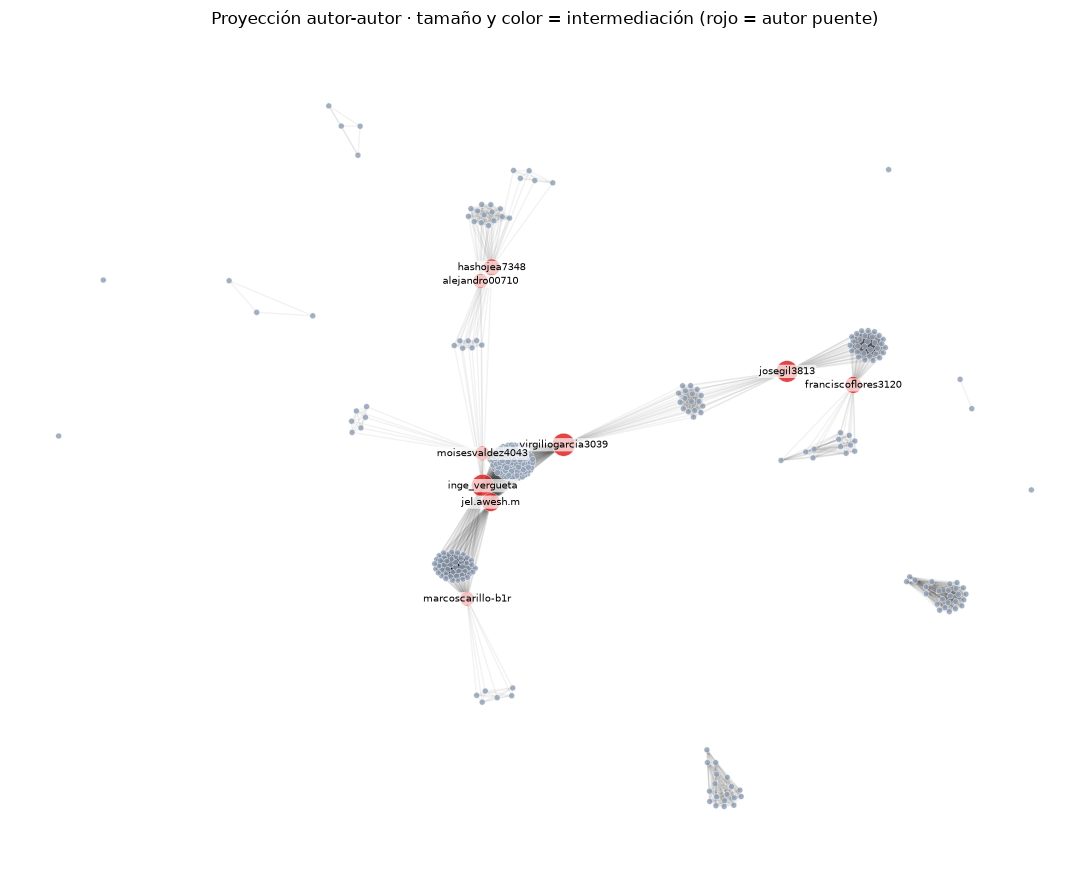

In [9]:
pos = nx.spring_layout(A, seed=42, weight="weight", k=0.22, iterations=80)
btw_series = centralidad_autores.set_index("author_channel_id")["intermediacion_A"]

fig, ax = plt.subplots(figsize=(11, 9))
tam = [18 + 520 * np.sqrt(btw_series.get(n, 0)) for n in A.nodes()]
col = ["#dc2626" if btw_series.get(n, 0) > 0 else "#94a3b8" for n in A.nodes()]
nx.draw_networkx_edges(A, pos, alpha=0.05, ax=ax)
nx.draw_networkx_nodes(A, pos, node_size=tam, node_color=col, alpha=0.85,
                       edgecolors="white", linewidths=0.3, ax=ax)
etiquetas = {
    n: A.nodes[n].get("author_handle", "")
    for n in btw_series[btw_series > 0].index if n in A.nodes
}
nx.draw_networkx_labels(A, pos, labels=etiquetas, font_size=7,
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
                        ax=ax)
ax.set_title("Proyección autor-autor · tamaño y color = intermediación (rojo = autor puente)")
ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURAS / "08_centralidad_autores.png", dpi=180, bbox_inches="tight")
plt.show()

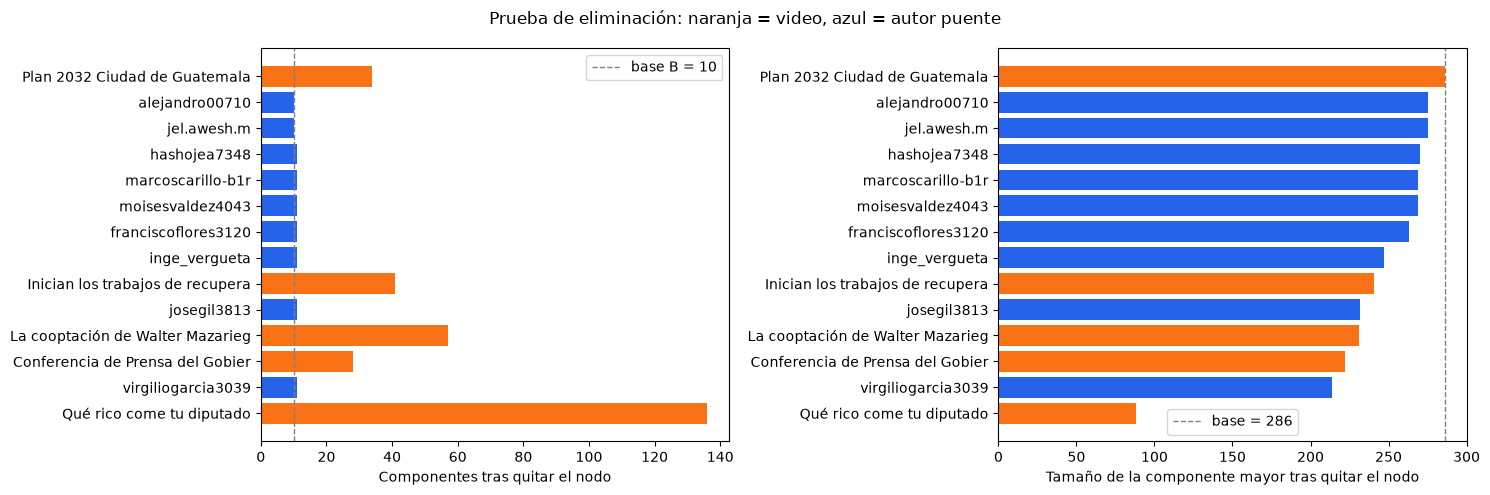

In [10]:
vis = articulacion.copy()
vis["nombre_corto"] = vis["etiqueta"].str.slice(0, 32).where(vis["etiqueta"] != "", vis["nodo"])
vis = vis.sort_values("mayor_tras_quitar")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(vis["nombre_corto"], vis["componentes_tras_quitar"],
             color=np.where(vis["tipo"] == "video", "#f97316", "#2563eb"))
axes[0].axvline(base_B, color="grey", ls="--", lw=1, label=f"base B = {base_B}")
axes[0].set_xlabel("Componentes tras quitar el nodo")
axes[0].legend()
axes[1].barh(vis["nombre_corto"], vis["mayor_tras_quitar"],
             color=np.where(vis["tipo"] == "video", "#f97316", "#2563eb"))
axes[1].axvline(286, color="grey", ls="--", lw=1, label="base = 286")
axes[1].set_xlabel("Tamaño de la componente mayor tras quitar el nodo")
axes[1].legend()
fig.suptitle("Prueba de eliminación: naranja = video, azul = autor puente")
fig.tight_layout()
fig.savefig(FIGURAS / "08_articulacion.png", dpi=180, bbox_inches="tight")
plt.show()

## 8.5. Hallazgos

- **Recurrencia y puente son fenómenos distintos y casi no coinciden.** Las cuentas que más comentan lo
  hacen dentro de un solo video; las que conectan videos comentan poco (2–4 veces) pero en 2–3 videos.
- **Solo 9 autores (2.7 %) sostienen la conexión entre camarillas.** Su intermediación es la única > 0
  en la proyección autor-autor. Quitar uno añade un componente, pero el efecto es pequeño.
- **Los verdaderos articuladores son los videos.** Eliminar de la bipartita el video con más
  comentaristas ("Qué rico come tu diputado") reduce la componente mayor de 286 a 88 nodos. La estructura
  de la red depende de qué videos entraron en la muestra, no de relaciones entre personas.
- Todo esto es **descripción de la muestra recolectada**, no una propiedad de las cuentas: no sabemos
  qué más comentaron esas personas fuera de los 19 videos observados.

In [11]:
# --- Auto-verificación ------------------------------------------------------
assert len(centralidad_autores) == 332, len(centralidad_autores)
assert len(centralidad_videos) == 19, len(centralidad_videos)

puente = centralidad_autores[centralidad_autores["intermediacion_A"] > 0]
assert len(puente) == 9, len(puente)
assert (puente["n_videos"] >= 2).all()

assert nx.number_connected_components(B) == 10
assert max(len(c) for c in nx.connected_components(B)) == 286
assert "componente" in centralidad_autores.columns

for f in ["centralidad_autores.csv", "centralidad_videos.csv", "centralidad_articulacion.csv"]:
    assert (TABLAS / f).exists(), f
for f in ["08_centralidad_autores.png", "08_articulacion.png"]:
    assert (FIGURAS / f).exists(), f

print("Etapa 8: self-check OK")
print(f"  {len(centralidad_autores)} autores, {len(centralidad_videos)} videos, "
      f"{len(puente)} autores puente (intermediacion > 0)")

Etapa 8: self-check OK
  332 autores, 19 videos, 9 autores puente (intermediacion > 0)
